In [1]:
%pip install adjustText
%pip install spacy
%pip install gensim
!python3 -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 15.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# You need to restart runtime after downloading en_core_web_md
To do so, go to the Runtime menu option and select restart session

In [3]:
# general
import os
import pandas as pd
import numpy as np
from numpy import dot
import re
import string
from collections import Counter

# stats and ML
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.model_selection import ShuffleSplit
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn import preprocessing

# plotting
import matplotlib.pyplot as plt
from matplotlib import pyplot
import seaborn as sns
from adjustText import adjust_text

# NLP specific libraries
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
snow_stemmer = SnowballStemmer(language='english')
from gensim.test.utils import common_texts
from gensim.models import Word2Vec, KeyedVectors
from gensim.models.word2vec import Word2Vec
import gensim.downloader as api
import spacy
from spacy.lang.en.examples import sentences
# load the model we just downloaded
spacy_model = spacy.load('en_core_web_md')
from textblob import TextBlob

os.mkdir('Week4')
# Change path
os.chdir('/content/Week4/')
# check path
print(os.getcwd())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


/content/Week4


Next, you will need to download the politeness github repo for the python version of the politeness package into Week4.

In [4]:
! git clone https://github.com/bbevis/politenessPy

Cloning into 'politenessPy'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 30 (delta 14), reused 20 (delta 7), pack-reused 0
Receiving objects: 100% (30/30), 74.03 KiB | 1.14 MiB/s, done.
Resolving deltas: 100% (14/14), done.


Once you have done this, your project folder should look like this:

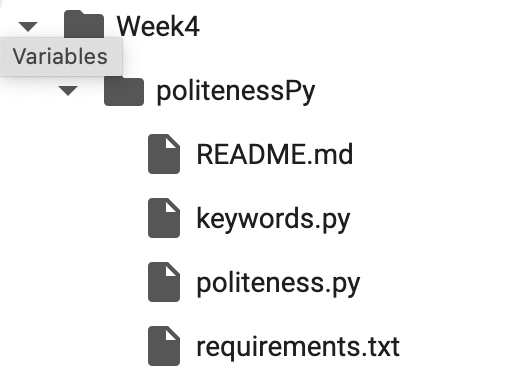

In [5]:
def stemming_tokenizer(str_input):

    # This function will be used to override basic preprocessing steps in TfidfVrctorizer

    words = re.sub(r"[^A-Za-z]", " ", str_input).lower().split()
    words = [snow_stemmer.stem(word) for word in words]

    return words

def TAB_dfm(text, ngrams_range = (1,2),
                stop_words = 'english', min_prop = .01,
                max_features=None):

  # TfidfVectorizer and CountVectorizer removes punctuation automatically
  # we also pass an earlier stemming_tokenizer function to the text
  # stopword options are either 'english' or False currently

  if stop_words == 'english':
    vec = CountVectorizer(
        tokenizer = stemming_tokenizer,
        stop_words = stop_words,
        ngram_range=ngrams_range,
        min_df=min_prop,
        max_features=max_features,
        token_pattern='(?u)\\b\\w+\\b'
        )
  else:
    vec = CountVectorizer(
        tokenizer = stemming_tokenizer,
        ngram_range=ngrams_range,
        min_df=min_prop,
        max_features=max_features,
        token_pattern='(?u)\\b\\w+\\b'
    )

  mtx = vec.fit_transform(text).todense()

  df = round(pd.DataFrame(mtx, columns=vec.get_feature_names_out()),2)

  return df, mtx


def kendall_acc(x,y,percentage = True):

  tau, p_value = stats.kendalltau(x, y)
  tau_acc = .5+tau/2
  tau_se = np.sqrt((tau_acc*(1 - tau_acc))/len(x))
  report = pd.DataFrame([tau_acc, tau_acc - 1.96 * tau_se, tau_acc + 1.96 * tau_se],
                        index = ['acc', 'lower', 'upper']).T
  report = round(report,4)

  if percentage is True:
    report = report * 100

  return report

# Jaccard Similarity is similar to bag of words similarity
# It is defined as size of intersection divided by size of union of two sets.
# Jaccard similarity takes only unique set of words for each sentence

def jaccard_sim(str1, str2):
    a = set(stemming_tokenizer(str1))
    b = set(stemming_tokenizer(str2))
    c = a.intersection(b)
    return float(len(c)) / (len(a) + len(b) - len(c))

# Euclidean distance
# This uses vectors created from our TAB_dfm function
def euclidian_dist(docs, y = 0):

    _, features = np.asarray(TAB_dfm(docs))
    distances = [round(float(euclidean_distances([features[y]], [f])),2) for f in features]

    return distances

# With cosine similarity, we need to convert sentences into vectors.
# cosine similarity takes total length of the vectors. (these vectors could be made from bag of words term frequency or tf-idf)
# Another way is to use Word2Vec or our own custom word embeddings to convert words into vectors.

def cosine_sim(docs, y = 0):

    _, features = np.asarray(TAB_dfm(docs, stop_words = False))
    distances = [round(float(cosine_similarity([features[y]], [f])),2) for f in features]

    return distances

def spacy_parse(text):
  # Python does not have it's own version of spacy_parse, but we can create our own

  nlp = spacy.load("en_core_web_sm")

  doc = nlp(text)

  rows = [[t.text, t.lemma_, t.pos_, t.tag_, t.dep_, spacy.explain(t.pos_), t.is_stop] for t in doc]

  cols = ("text", "lemma", "POS", "Tag","Dep","explain", "stopword")
  df = pd.DataFrame(rows, columns=cols)

  return df

def lemmas_parse(text):

  # we can use lemmas instead of stemmed words
  # for each doc, extract all lemmas that are not pronouns, numbers, symbols, stopwords, spaces or punctuations

  nlp = spacy.load("en_core_web_sm")
  doc = nlp(text)

  lemmas = [t.lemma_ for t in doc
          if t.pos_ not in ('SPACE', 'PRON', 'PUNCT', 'NUM', 'SYM')
          if t.is_stop == False]

  return ' '.join(lemmas)

def lemmas_dfm(texts):

  dfms_joined = pd.DataFrame()

  for text in texts:

    text = [lemmas_parse(text)]

    if len(text[0]) > 1:
      dfm, _ = TAB_dfm(text, ngrams_range=(0,1), stop_words = False)
      dfms_joined = dfms_joined.append(dfm)

  return dfms_joined

# Get names entities
def ner_parse(text):

  nlp = spacy.load("en_core_web_sm")
  doc = nlp(text)

  rows = [[ent.text, ent.start_char, ent.end_char, ent.label_] for ent in doc.ents]

  cols = ("Text", "Start", "End", "Label")
  df = pd.DataFrame(rows, columns=cols)

  return df

def ner_filter_parse(text):

  nlp = spacy.load("en_core_web_sm")
  doc = nlp(text)

  ents = [ent.text for ent in doc.ents
          if ent.label_ == 'GPE']

  return ' '.join(list(set(ents)))

def ner_dfm(texts):

  dfms_joined = pd.DataFrame()
  for text in texts:
    text = [ner_filter_parse(text)]

    if len(text[0]) > 1:
      dfm, _ = TAB_dfm(text, ngrams_range=(0,1), stop_words = False)

      dfms_joined = dfms_joined.append(dfm)

  return dfms_joined

def tokenizer(str_input):

    # This function will be used to override basic preprocessing steps in TfidfVrctorizer

    words = re.sub(r"[^A-Za-z]", " ", str_input).lower().split()

    return words

def dfm_lookup(text,
               dict_as_list,
               ngrams_range = (1,1),
               min_prop = .01,
               max_features=None):

  # TfidfVectorizer and CountVectorizer removes punctuation automatically
  # we pass an earlier tokenizer function to the text
  # stopword options is set to 'english'

  vec = CountVectorizer(
      tokenizer = tokenizer,
      stop_words = 'english',
      ngram_range=ngrams_range,
      min_df=min_prop,
      max_features=max_features,
      token_pattern='(?u)\\b\\w+\\b'
      )

  mtx = vec.fit_transform(text).todense()
  df = round(pd.DataFrame(mtx, columns=vec.get_feature_names_out()),2)

  df = df[df.columns.intersection(dict_as_list)]

  row_sums = df.sum(axis=1)

  return row_sums

Upload cfpb_small.csv, vecSmall.csv, wfFile.csv and Loughran-McDonald_MasterDictionary_1993-2023.csv from github into the Week4 folder.

Note that both cfpb_small.csv and vecSmall.csv are very large. On the bottom left, check that the upload is fully finished by checking the blue circle status. This may take a few minutes.


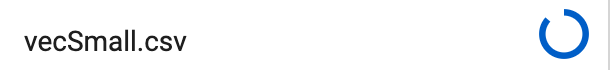

In addition, this week requires the Loughran-McDonald dictionary to be uploaded as a CSV. Once everything is uploaded, your final project folder should look like this:

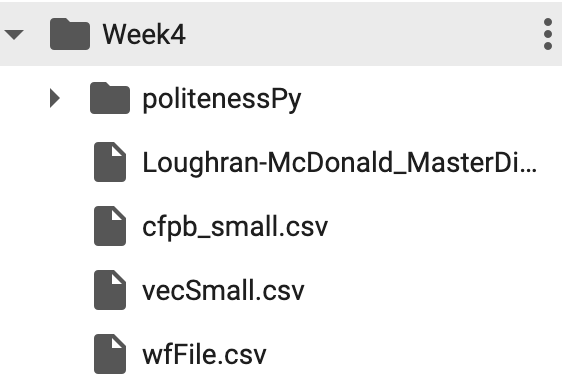

In [ ]:
cfpb_small = pd.read_csv('cfpb_small.csv')
cfpb_small = cfpb_small[cfpb_small['Product'] == "Credit reporting"]

# number of rows and columns in original dataframe
print(cfpb_small.shape)

cfpb_small = cfpb_small.sample(n=2000, random_state=42)
#colab can't handle too much data. Note that the solution in R uses 12,000 samples.
# to ensure we do not exceed the limit for colab, set sample size to 2000
print(cfpb_small.shape)
print(list(cfpb_small))

(15000, 22)
(2000, 22)
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Complaint ID', 'year', 'redact_count', 'narr_wdct', 'timely', 'disputed', 'issue_n']


In [ ]:
vecSmall = pd.read_csv('vecSmall.csv', index_col= 0)
print(vecSmall.head())

     0.0231   0.017  0.0157  -0.0773  0.1088  0.0031  -0.1487  -0.2672  \
the                                                                      
and -0.1081  0.0191  0.0354   0.0127  0.0664 -0.0126  -0.1882   0.0631   
to  -0.0175 -0.2189  0.0353   0.0345  0.0913  0.0269  -0.1670  -0.2759   
of   0.0095  0.0379 -0.0313  -0.1041 -0.0045 -0.0271  -0.2004  -0.1251   
a    0.0064  0.0333  0.0225  -0.1139  0.0166 -0.0088  -0.0673   0.0601   
in  -0.0037  0.1510  0.0568  -0.0288 -0.0023  0.0332  -0.0273   0.3054   

     -0.0357  -0.0487  ...  -8.00E-04  0.0052  -0.0363  -0.2508  0.1252  \
the                    ...                                                
and  -0.2306   0.0095  ...     0.0608  0.0227  -0.0306   0.3945  0.0200   
to    0.4283   0.0349  ...     0.0642  0.0136   0.0367   0.1735  0.0217   
of    0.0341  -0.0019  ...     0.0067  0.0224   0.0300  -0.2433 -0.0155   
a    -0.0505   0.0388  ...     0.0061 -0.0025   0.0935  -0.0654  0.0268   
in    0.3557  -0.0257  ...     

In [ ]:
# Word frequency file - to reweight common words
wfFile = pd.read_csv('wfFile.csv', index_col= 0)
print(wfFile.head())

      FREQcount  CDcount  FREQlow  Cdlow   SUBTLWF  Lg10WF  SUBTLCD  Lg10CD  \
Word                                                                          
the     1501908     8388  1339811   8388  29449.18  6.1766   100.00  3.9237   
to      1156570     8383  1138435   8380  22677.84  6.0632    99.94  3.9235   
a       1041179     8382   976941   8380  20415.27  6.0175    99.93  3.9234   
you     2134713     8381  1595028   8376  41857.12  6.3293    99.92  3.9233   
and      682780     8379   515365   8374  13387.84  5.8343    99.89  3.9232   

       FREQavg  
Word            
the   0.030208  
to    0.023262  
a     0.020941  
you   0.042935  
and   0.013733  


In [ ]:
# Randomly choose 50% for test and 50% for training data
sss = ShuffleSplit(n_splits=1, test_size=0.5, random_state = 42)

sss.get_n_splits(cfpb_small)
train_index, test_index = next(sss.split(cfpb_small))

cfpb_small_train = cfpb_small.iloc[train_index]
cfpb_small_test = cfpb_small.iloc[test_index]

#############################################
# project data to embedding space

In [ ]:
# The below is a Python equivalent to the vecCheck function in the vectorFunctions.R script
# Define a pipeline for projecting data into embedding space
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(vocabulary=wfFile.index)),  # Use word frequency as vocabulary
    ('lsa', TruncatedSVD(n_components=vecSmall.shape[1])),  # Use the same dimensionality as the pre-trained model
])

# Fit the pipeline on your data
pipeline.fit(cfpb_small['narrative'])

# Transform data to embedding space
vdat = pipeline.transform(cfpb_small['narrative'])

# Convert the embedded data into a DataFrame
vdat = pd.DataFrame(vdat, columns=[f'vec{i+1}' for i in range(vdat.shape[1])])
print(vdat.head())

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:1380: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(


       vec1      vec2      vec3      vec4      vec5      vec6      vec7  \
0  0.551273  0.047864 -0.033363  0.188212 -0.026505 -0.081322  0.054608   
1  0.546699  0.258609 -0.104400  0.197656  0.119219  0.015061  0.048056   
2  0.297484 -0.069507 -0.076503 -0.129358  0.073521 -0.132014 -0.014369   
3  0.284667  0.062811 -0.009201  0.130054 -0.069442  0.016280  0.181297   
4  0.331414 -0.035332 -0.087314  0.004482  0.111009 -0.104079 -0.078846   

       vec8      vec9     vec10  ...    vec291    vec292    vec293    vec294  \
0  0.161762 -0.093996  0.008859  ... -0.006143 -0.041074 -0.069428 -0.027364   
1  0.138706  0.034067 -0.140592  ...  0.011836 -0.010438 -0.011224 -0.040704   
2  0.046568  0.018918 -0.062679  ...  0.047143  0.054122  0.000543 -0.031917   
3 -0.053931  0.161375  0.076248  ...  0.027988  0.004452  0.014070  0.042683   
4 -0.053930  0.079740  0.008947  ...  0.013024 -0.017500  0.014360 -0.017145   

     vec295    vec296    vec297    vec298    vec299    vec300  
0 -0

In [ ]:
vdat_train = vdat.iloc[train_index]
vdat_test = vdat.iloc[test_index]

In [ ]:
vdat # we should have a dataframe where each column is a vector

,vec1,vec2,vec3,vec4,vec5,vec6,vec7,vec8,vec9,vec10,...,vec291,vec292,vec293,vec294,vec295,vec296,vec297,vec298,vec299,vec300
0,0.551273,0.047864,-0.033363,0.188212,-0.026505,-0.081322,0.054608,0.161762,-0.093996,0.008859,...,-0.006143,-0.041074,-0.069428,-0.027364,-0.010269,-0.055054,0.020372,-0.005605,-0.018103,0.011035
1,0.546699,0.258609,-0.104400,0.197656,0.119219,0.015061,0.048056,0.138706,0.034067,-0.140592,...,0.011836,-0.010438,-0.011224,-0.040704,0.000035,-0.003561,-0.005760,0.010523,-0.008288,-0.011987
2,0.297484,-0.069507,-0.076503,-0.129358,0.073521,-0.132014,-0.014369,0.046568,0.018918,-0.062679,...,0.047143,0.054122,0.000543,-0.031917,0.016706,-0.025080,0.027513,0.046236,0.034952,-0.037534
3,0.284667,0.062811,-0.009201,0.130054,-0.069442,0.016280,0.181297,-0.053931,0.161375,0.076248,...,0.027988,0.004452,0.014070,0.042683,0.023440,0.006601,-0.045390,-0.055579,0.013964,-0.021858
4,0.331414,-0.035332,-0.087314,0.004482,0.111009,-0.104079,-0.078846,-0.053930,0.079740,0.008947,...,0.013024,-0.017500,0.014360,-0.017145,-0.002220,0.025756,-0.033209,-0.052915,0.025038,0.052967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.379787,-0.053839,-0.011032,0.037896,-0.146288,0.056798,0.009242,0.005645,0.109366,0.000494,...,-0.014584,-0.009720,-0.055617,-0.005850,-0.060689,-0.045489,-0.033567,-0.009297,0.005088,0.019917
1996,0.377865,-0.095239,-0.021780,-0.016695,0.064552,-0.114121,-0.113022,0.029085,0.182382,0.028519,...,0.106573,-0.024997,0.045371,0.023861,0.039317,0.015657,0.004609,0.007735,-0.003207,-0.014631
1997,0.332470,-0.048544,-0.053833,-0.109968,-0.111618,0.064641,0.089220,-0.012348,0.167168,0.139437,...,0.084423,-0.024888,0.024389,0.006570,-0.025097,0.013238,-0.016463,-0.021062,-0.005906,0.008293
1998,0.398294,-0.059095,0.207512,-0.017758,0.021979,-0.122196,-0.034330,0.027270,-0.028986,-0.038588,...,-0.021688,-0.002651,-0.033015,0.005388,0.007801,0.016157,0.018984,0.020839,0.019122,-0.029407


#############################################
# Train a vector classifier

In [ ]:
# Put training data into LASSO model
Lasso_vec = Lasso(alpha = 0.001)

Lasso_vec.fit(vdat_train, cfpb_small_train['disputed'])
test_predict = Lasso_vec.predict(vdat_test)

# Estimate accuracy
vec_acc = kendall_acc(test_predict, cfpb_small_test['disputed'])

print(vec_acc)

     acc  lower  upper
0  55.54  52.46  58.62


#############################################
# vector embeddings + ngrams

In [ ]:
cfpb_small_dfm_train, _ = TAB_dfm(cfpb_small_train['narrative'])
cfpb_small_dfm_test, _ = TAB_dfm(cfpb_small_test['narrative'], min_prop = 0)

d = [list(cfpb_small_dfm_train), list(cfpb_small_dfm_test)]
col_heads = list(set.intersection(*map(set,d)))

# check that we have a list of terms
col_heads[2:10]

# Everything must have the same column headers in the dfm
cfpb_small_dfm_train = cfpb_small_dfm_train[col_heads].reset_index(drop = True)
cfpb_small_dfm_test = cfpb_small_dfm_test[col_heads].reset_index(drop = True)

vdat_train = vdat_train.reset_index(drop = True)
vdat_test = vdat_test.reset_index(drop = True)

combined_x_train = pd.concat([vdat_train, cfpb_small_dfm_train], axis = 1)
combined_x_test = pd.concat([vdat_test, cfpb_small_dfm_test], axis = 1)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

In [ ]:
print(vdat_train.shape)
print(cfpb_small_dfm_train.shape)
print(combined_x_train.shape)

# Row numbers should be the same

(1000, 300)
(1000, 1209)
(1000, 1509)


In [ ]:
# Put training data into LASSO model
lasso_all = Lasso(alpha = 0.001)

lasso_all.fit(combined_x_train, cfpb_small_train['disputed'])
test_all_predict = lasso_all.predict(combined_x_test)

# Estimate accuracy
ngram_vec_acc = kendall_acc(test_all_predict, cfpb_small_test['disputed'])

print(ngram_vec_acc)

     acc  lower  upper
0  54.09   51.0  57.18


#############################################
# ngrams alone

In [ ]:
# Put training data into LASSO model
lasso_dfm = Lasso(alpha = 0.001)

lasso_all.fit(cfpb_small_dfm_train, cfpb_small_train['disputed'])
test_dfm_predict = lasso_all.predict(cfpb_small_dfm_test)

# Estimate accuracy
ngram_acc = kendall_acc(test_dfm_predict, cfpb_small_test['disputed'])

print(ngram_acc)

     acc  lower  upper
0  54.09   51.0  57.18


########################################
# Benchmarks
########################################

In [ ]:
cfpb_small_test['wdct'] = cfpb_small_test['narrative'].apply(lambda x: len(str(x).split()))
cfpb_small_test['sentiment'] = cfpb_small_test['narrative'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

wdct_acc = kendall_acc(cfpb_small_test['wdct'], cfpb_small_test['disputed'])

sentiment_acc = kendall_acc(cfpb_small_test['sentiment'], cfpb_small_test['disputed'])

print(wdct_acc)
print(sentiment_acc)

########################################
# Combine accuracy estimates for a plot
########################################

In [ ]:
plot_dat = pd.concat([ngram_acc, vec_acc, ngram_vec_acc, wdct_acc, sentiment_acc])
plot_dat['features'] = ['ngrams', 'w2v', 'ngrams+w2v', 'word count', 'sentiment']
plot_dat['err'] = plot_dat['acc'] - plot_dat['lower']

print(plot_dat)

     acc  lower  upper    features   err
0  54.09  51.00  57.18      ngrams  3.09
0  55.54  52.46  58.62         w2v  3.08
0  54.09  51.00  57.18  ngrams+w2v  3.09
0  52.88  49.79  55.97  word count  3.09
0  48.52  45.42  51.62   sentiment  3.10


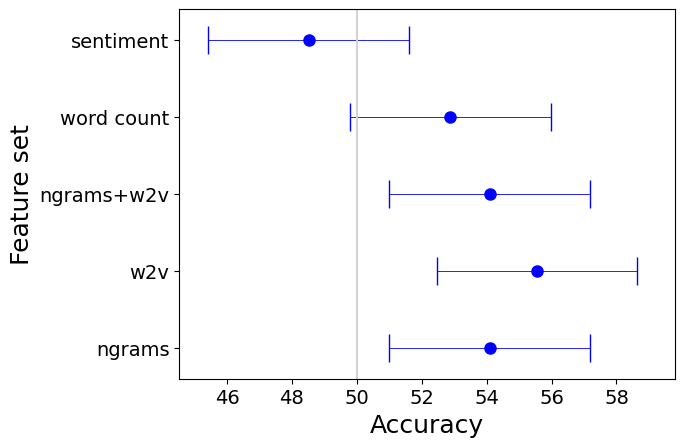

In [ ]:

fig = plt.figure()
plt.errorbar(y = plot_dat['features'], x = plot_dat['acc'], xerr=plot_dat['err'], fmt="o", color="b", elinewidth=.6, markersize=8, capsize=10)

plt.grid(False)
plt.axvline(x=50, color='lightgrey', linestyle='-')
# add axis labels
plt.xlabel('Accuracy', fontsize=18)
plt.ylabel('Feature set', fontsize=18)
# Makes the margins a bit wider (useful when there's only 2 points)
plt.margins(0.1, tight=True)

# set the height of the yaxis to be proportional to the data
plt.xlim(right=((max(plot_dat['acc']) + max(plot_dat['err']))) * 1.02,
         left=((min(plot_dat['acc']) - min(plot_dat['err']))) * 0.98)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()


######################################################################
# Distributed Dictionary
######################################################################


In [ ]:
# extract dictionary as document
# Load Loughran & McDonald uncertainty dictionary
uncertainty_dictionary = pd.read_csv('Loughran-McDonald_MasterDictionary_1993-2023.csv')
uncertainty_dictionary['Word'] = uncertainty_dictionary['Word'].str.lower()
uncertainty_dictionary = uncertainty_dictionary['Word'][uncertainty_dictionary['Uncertainty'] != 0]
uncertainty_dictionary = ' '.join(uncertainty_dictionary.to_list())
# _, uncertainty_dictionary = np.asarray(TAB_dfm([uncertainty_dictionary], stop_words = False))

# Fit the pipeline on your data
# pipeline.fit([uncertainty_dictionary])

# # Transform data to embedding space
# uncertainty_dictionary = pipeline.transform([uncertainty_dictionary])

uncertainty_dictionary

'abeyance abeyances almost alteration alterations ambiguities ambiguity ambiguous anomalies anomalous anomalously anomaly anticipate anticipated anticipates anticipating anticipation anticipations apparent apparently appear appeared appearing appears approximate approximated approximately approximates approximating approximation approximations arbitrarily arbitrariness arbitrary assume assumed assumes assuming assumption assumptions believe believed believes believing cautious cautiously cautiousness clarification clarifications conceivable conceivably conditional conditionally confuses confusing confusingly confusion contingencies contingency contingent contingently contingents could crossroad crossroads depend depended dependence dependencies dependency dependent depending depends destabilizing deviate deviated deviates deviating deviation deviations differ differed differing differs doubt doubted doubtful doubts exposure exposures fluctuate fluctuated fluctuates fluctuating fluctuat

In [ ]:
# Add dictionary to list of narratives - easier to do vectorisation on one list to get the same dimensions
narratives = cfpb_small_train['narrative'].to_list()
narratives.insert(0, uncertainty_dictionary)

In [ ]:
# Fit the pipeline on your data
pipeline.fit(narratives)
# Transform data to embedding space
narratives = pipeline.transform(narratives)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:1380: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(


In [ ]:
uncertainty_scores = [round(float(cosine_similarity([narratives[0]], [n])),5) for n in narratives]

# there are a lot of deprecation warnings. The code does work, but a better alternative to get around
# the deprecation warning has yet to present itself to me. The reason is...
# cosine_similarites requires arrays of x and y as inputs, yet the deprecation warning asks
# you to use a single element from your array. A tad paradoxical.

In [ ]:
print(uncertainty_scores)
print(len(uncertainty_scores))


[1.0, -0.0099, -0.00467, 0.00558, -0.01323, -0.00433, -0.00125, -0.01164, 0.00538, -0.00372, 0.00965, -0.00375, 0.0017, 0.00929, -0.00257, 0.02205, -0.00146, -0.0122, 0.00823, 0.01702, 0.00651, 0.00963, -0.00272, -0.0022, 0.01734, 0.00546, 0.002, -0.00063, -0.0021, -0.00882, 0.00884, -0.00361, 0.00187, -0.02755, 0.00371, -0.03674, 0.02411, -0.00148, 0.01607, -0.00255, -1e-05, -0.00371, -0.01868, -0.00083, -0.01345, -4e-05, -0.01158, 0.00527, -0.00035, 0.01437, -0.02146, -0.00296, -0.00838, 0.01113, 0.00447, 0.00506, 0.009, -0.00673, 0.00057, 0.00589, -0.00235, 0.01008, 0.00624, -0.00317, 0.00282, -0.00011, -0.00489, 0.02532, 0.00775, 0.01026, 0.01258, -0.00417, 0.02796, 0.02988, -0.00021, -0.00142, -0.01328, 0.0018, -0.00164, -0.01872, 0.00565, 0.00525, -0.01259, -0.00401, 0.00345, 0.00083, 0.01808, 0.00409, 0.0154, 0.00414, -0.00293, 0.02138, -0.0106, -0.01998, -0.00652, 0.03268, 0.00956, 0.01048, -0.00692, 0.0139, -0.00222, -0.00803, 0.00068, 0.00015, -0.00425, -0.00081, 0.00293, -0.

In [ ]:
# remove first value to remove first value
print(len(uncertainty_scores))
print(len(cfpb_small_train['narrative']))

uncertainty_scores.pop(0)
print(len(uncertainty_scores))

1001
1000
1000


In [ ]:
# add the similarity scores to the dataframe
cfpb_small_train['uncertain_sim'] = uncertainty_scores
# add the similarity scores to the dataframe
# cfpb_small_train

<ipython-input-28-f28bdeaf942c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cfpb_small_train['uncertain_sim'] = uncertainty_scores


In [ ]:
# because the dataset is small, we need to remove rows where there is only one sub-issue
# Count occurrences of each value in Column1
value_counts = cfpb_small_train['Sub-issue'].value_counts()
# Filter out rows where the value appears only once
cfpb_small_train_trim = cfpb_small_train[cfpb_small_train['Sub-issue'].isin(value_counts.index[value_counts.gt(1)])]

# Calculate mean and standard error by categories
plot_dat = cfpb_small_train_trim.groupby('Sub-issue')['uncertain_sim'].agg(['mean', 'std'])

# Calculate standard error (assuming the number of observations per group is known)
plot_dat['stderr'] = plot_dat['std'] / (cfpb_small_train_trim.groupby('Sub-issue')['uncertain_sim'].count() ** 0.5)

plot_dat = plot_dat.reset_index().sort_values(by = 'mean', ascending=False)
plot_dat

,Sub-issue,mean,std,stderr
2,Account terms and changes,0.007132,0.014875,0.004958
16,Report improperly shared by CRC,0.006343,0.013947,0.002262
12,Problem with fraud alerts,0.006050,0.015666,0.005222
3,Billing dispute,0.005977,0.008738,0.002060
11,Problem getting report or credit score,0.005097,0.012714,0.002090
8,Personal information,0.004219,0.011894,0.002289
14,Public record,0.003507,0.013009,0.001335
10,Problem getting my free annual report,0.002855,0.011801,0.001843
7,No notice of investigation status/result,0.002827,0.009627,0.000935
1,Account terms,0.002529,0.009954,0.001061


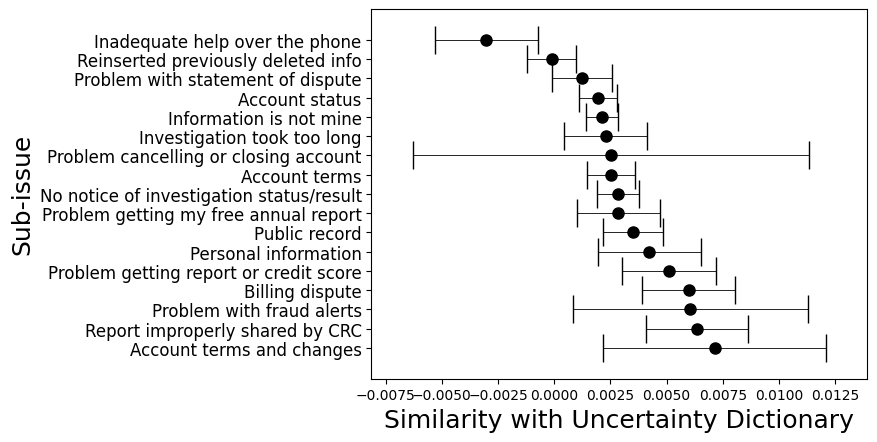

In [ ]:
fig = plt.figure()
plt.errorbar(y = plot_dat['Sub-issue'], x = plot_dat['mean'], xerr=plot_dat['stderr'], fmt="o", color="black", elinewidth=.6, markersize=8, capsize=10)

# add axis labels
plt.xlabel('Similarity with Uncertainty Dictionary', fontsize=18)
plt.ylabel('Sub-issue', fontsize=18)
# Makes the margins a bit wider (useful when there's only 2 points)
plt.margins(0.1, tight=True)

plt.xticks(fontsize=10)
plt.yticks(fontsize=12)

plt.show()

In [ ]:
# estimate accuracy
kendall_acc(uncertainty_scores, cfpb_small_train['disputed'])

,acc,lower,upper
0,50.69,47.59,53.79


#############################################
# extract dictionary the normal way
#############################################

In [ ]:
# create dfms for each document without stemming or lemmatisation
# subset dfm base on list of words in dictionary

uncertainty_dictionary = pd.read_csv('Loughran-McDonald_MasterDictionary_1993-2023.csv')
uncertainty_dictionary['Word'] = uncertainty_dictionary['Word'].str.lower()
uncertainty_dictionary = uncertainty_dictionary['Word'][uncertainty_dictionary['Uncertainty'] != 0].to_list()

# uncertainty_dictionary needs to be in a list

cfpb_small_train_dicts = dfm_lookup(cfpb_small_train['narrative'], uncertainty_dictionary)

In [ ]:
kendall_acc(cfpb_small_train_dicts, cfpb_small_train['disputed'])

,acc,lower,upper
0,48.9,45.8,52.0


#############################################

**Politeness in python**

#############################################

In [ ]:
import sys
sys.path.append('/content/Week4/politenessPy')
import keywords

from politenessPy.politeness import *

text = 'Hello! I understand your perspective, but I do not agree with your point of view.'
recp = politeness(text)

features = recp.extract_features(text)
print(features)

Runtime:  0.043
               features  feature_counts  Counts_norm
0   First_Person_Single               2    11.111111
1         Second_Person               2    11.111111
2       Acknowledgement               1     5.555556
3              Negation               1     5.555556
4                 Hello               1     5.555556
5          Disagreement               1     5.555556
29           By_The_Way               0     0.000000
24  First_Person_Plural               0     0.000000
25         Filler_Pause               0     0.000000
26            Could_You               0     0.000000
27    Conjunction_Start               0     0.000000
28              Can_You               0     0.000000
32            Agreement               0     0.000000
30           Ask_Agency               0     0.000000
31              Apology               0     0.000000
22              For_You               0     0.000000
33    Truth_Intensifier               0     0.000000
34         Bare_Command       

In [ ]:
# Apply the extract_features function to the narrative column
docs = cfpb_small_train['narrative'].to_list()

narrative_features = pd.DataFrame()

for d in range(len(docs)):
  features = recp.extract_features(docs[d])
  features['doc_id'] = 'text' + str(d)
  narrative_features = pd.concat([narrative_features, features])



In [ ]:
print(narrative_features)

               features  feature_counts  Counts_norm   doc_id
0    Impersonal_Pronoun               5     7.246377    text0
1   First_Person_Single               4     5.797101    text0
2             Gratitude               2     2.898551    text0
3      Negative_Emotion               2     2.898551    text0
4                Please               1     1.449275    text0
..                  ...             ...          ...      ...
8           Let_Me_Know               0     0.000000  text999
7        Informal_Title               0     0.000000  text999
6                 Hello               0     0.000000  text999
37       Adverb_Limiter               0     0.000000  text999
38          Token_count             103   100.000000  text999

[39000 rows x 4 columns]


Note that the full implementation of the politeness package is not yet available in Python and the charting functionality does not yet exist

##################################################
# Comparing lemmas and stems
##################################################

In [ ]:
# cfpb_tiny = cfpb_small_train[cfpb_small_train[]]

# Count occurrences of each value in Column1
value_counts = cfpb_small_train['Company'].value_counts()
# Filter out rows where the value appears only once
cfpb_tiny = cfpb_small_train[cfpb_small_train['Company'].isin(value_counts.index[value_counts.gt(1)])]

cfpb_tiny = cfpb_tiny.sample(n=20).reset_index()


In [ ]:
lemmas_parse(cfpb_tiny['narrative'][1])

'XXXX XXXX/2016 XXXX ultimately direct experian website obtain XXXX bureau credit report ultiamtely pay despite freecreditreport.com imply fee credit report deceptive problem agree cost XXXX XXXX/2016 XXXX XXXX XXXX charge authorization need refund step take cancel recur billing habit avoid type situation bit outrage credit reporting agency engage kind behavior expect local gym forgot cancel recur billing organization like Experian suppose able trust agent speak today XXXX XXXX/2016 XXXX XXXX name XXXX employee ID # xxxx helpful understanding possible indicate supervisor authorize XXXX refund charge charge valid reverse clear acknowledge fact cancel billing describe essence ask pay mistake unfair call explain give access credit information day get email downgrading request later agent XXXX inform pay day access lot confusion thing go'

In [ ]:
cfpb_tiny_sp = pd.DataFrame()

for i in range(len(cfpb_tiny['narrative'])):
  cfpb_tiny['lemmas'] = lemmas_parse(cfpb_tiny['narrative'][i]) # recreate documents from the lemmas
  cfpb_tiny_text = spacy_parse(cfpb_tiny['lemmas'][i]) #extract lemmas as words from the document
  cfpb_tiny_text['doc_id'] = 'text' + str(i + 1)
  cfpb_tiny_sp = pd.concat([cfpb_tiny_sp,cfpb_tiny_text])


In [ ]:
cfpb_tiny_sp

,text,lemma,POS,Tag,Dep,explain,stopword,doc_id
0,Fair,fair,NOUN,NN,compound,noun,False,text1
1,Credit,Credit,PROPN,NNP,compound,proper noun,False,text1
2,Reporting,Reporting,PROPN,NNP,compound,proper noun,False,text1
3,Act,Act,PROPN,NNP,compound,proper noun,False,text1
4,U.S.C.,U.S.C.,PROPN,NNP,compound,proper noun,False,text1
...,...,...,...,...,...,...,...,...
29,soon,soon,ADV,RB,advmod,adverb,False,text20
30,possible,possible,ADJ,JJ,amod,adjective,False,text20
31,thank,thank,VERB,VBP,amod,verb,False,text20
32,attention,attention,NOUN,NN,compound,noun,False,text20


In [ ]:
cfpb_tiny_sp.shape

(1341, 8)

In [ ]:
stemming_tokenizer(cfpb_tiny_sp['text'].iloc[0])[0]

'fair'

In [ ]:
stems = []

for i in range(len(cfpb_tiny_sp['text'])):
  # print(i)
  if len(stemming_tokenizer(cfpb_tiny_sp['text'].iloc[i])) != 0:
    stems.append(stemming_tokenizer(cfpb_tiny_sp['text'].iloc[i])[0])
  else:
    stems.append('NOT A WORD')


cfpb_tiny_sp['stem'] = stems



In [ ]:
# 20 words where lemmas and stems are different
cfpb_tiny_sp[cfpb_tiny_sp['stem'] != cfpb_tiny_sp['lemma']][:20]

,text,lemma,POS,Tag,Dep,explain,stopword,doc_id,stem
1,Credit,Credit,PROPN,NNP,compound,proper noun,False,text1,credit
2,Reporting,Reporting,PROPN,NNP,compound,proper noun,False,text1,report
3,Act,Act,PROPN,NNP,compound,proper noun,False,text1,act
4,U.S.C.,U.S.C.,PROPN,NNP,compound,proper noun,False,text1,u
8,Credit,Credit,PROPN,NNP,compound,proper noun,False,text1,credit
9,Bureau,Bureau,PROPN,NNP,nsubj,proper noun,False,text1,bureau
10,disclose,disclose,VERB,VB,ROOT,verb,False,text1,disclos
23,copy,copy,NOUN,NN,compound,noun,False,text1,copi
26,verify,verify,VERB,VBP,compound,verb,False,text1,verifi
27,documentation,documentation,NOUN,NN,compound,noun,False,text1,document


In [ ]:
# Most common noun phrases

cfpb_tiny_sp = pd.DataFrame()

for i in range(len(cfpb_tiny['narrative'])):
  cfpb_tiny_text = spacy_parse(cfpb_tiny['narrative'][i]) #extract lemmas as words from the document
  cfpb_tiny_sp = pd.concat([cfpb_tiny_sp,cfpb_tiny_text])

In [ ]:
cfpb_tiny_sp = cfpb_tiny_sp[['text', 'POS']]
cfpb_tiny_sp = cfpb_tiny_sp[cfpb_tiny_sp['POS'] == 'NOUN']

# Calculate mean and standard error by categories
top_30_nouns = cfpb_tiny_sp.groupby('text').agg('count').sort_values(by = 'POS', ascending=False)[:30].reset_index()
top_30_nouns.rename(columns = {'POS': 'Count'})


,text,Count
0,credit,46
1,report,27
2,accounts,21
3,XXXX,17
4,account,17
5,information,13
6,dispute,11
7,loan,10
8,judgment,8
9,file,8
